In [1]:
import scanpy as sc
import torch
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
os.chdir("/public/home/off_liukunpeng/project/11_cluster_problem/")
import sys
sys.path.append("/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/")
from matplotlib.lines import Line2D
import numpy as np
import glob
import AgaeSMO as AgaeSMO

In [2]:
from sklearn import metrics
def supervise_index(adata,predict,real_key):
    
    ARI = metrics.adjusted_rand_score(adata.obs[real_key],adata.obs[predict])
    NMI = metrics.normalized_mutual_info_score(adata.obs[real_key],adata.obs[predict])
    FMS = metrics.fowlkes_mallows_score(adata.obs[real_key],adata.obs[predict])
    AMI = metrics.adjusted_mutual_info_score(adata.obs[real_key],adata.obs[predict])
    HMG = metrics.homogeneity_score(adata.obs[real_key],adata.obs[predict])
    VMS = metrics.v_measure_score(adata.obs[real_key],adata.obs[predict])
    MIS = metrics.mutual_info_score(adata.obs[real_key],adata.obs[predict])
    return {"ARI":ARI,
            "NMI":NMI,
            "FMS":FMS,
            "AMI":AMI,
            "HMG":HMG,
            "VMS":VMS,
            'MIS':MIS}
def search_res(adata, n_clusters, method='leiden', use_rep='emb', start=0.1, end=3.0, increment=0.01):
    '''\
    Searching corresponding resolution according to given cluster number
    
    Parameters
    ----------
    adata : anndata
        AnnData object of spatial data.
    n_clusters : int
        Targetting number of clusters.
    method : string
        Tool for clustering. Supported tools include 'leiden' and 'louvain'. The default is 'leiden'.    
    use_rep : string
        The indicated representation for clustering.
    start : float
        The start value for searching.
    end : float 
        The end value for searching.
    increment : float
        The step size to increase.
        
    Returns
    -------
    res : float
        Resolution.
        
    '''
    print('Searching resolution...')
    label = 0
    sc.pp.neighbors(adata, n_neighbors=50, use_rep=use_rep)
    for res in sorted(list(np.arange(start, end, increment)), reverse=True):
        if method == 'leiden':
           sc.tl.leiden(adata, random_state=0, resolution=res)
           count_unique = len(pd.DataFrame(adata.obs['leiden']).leiden.unique())
           print('resolution={}, cluster number={}'.format(res, count_unique))
        elif method == 'louvain':
           sc.tl.louvain(adata, random_state=0, resolution=res)
           count_unique = len(pd.DataFrame(adata.obs['louvain']).louvain.unique()) 
           print('resolution={}, cluster number={}'.format(res, count_unique))
        if count_unique == n_clusters:
            label = 1
            break

    assert label==1, "Resolution is not found. Please try bigger range or smaller step!." 
       
    return res  

In [4]:
path=glob.glob("down_stream_analysis/simulation_cluster/*csv")


In [5]:
path=[
'down_stream_analysis/simulation_cluster/STAGATE.csv',
'down_stream_analysis/simulation_cluster/STMGraph.csv',
'down_stream_analysis/simulation_cluster/SpaGCN.csv',
'down_stream_analysis/simulation_cluster/deepst.csv',
''
'down_stream_analysis/simulation_cluster/MOFA.csv',
'down_stream_analysis/simulation_cluster/MultiVI.csv',
'down_stream_analysis/simulation_cluster/ToltalVI.csv',
'down_stream_analysis/simulation_cluster/SpatialGlue.csv',
'down_stream_analysis/simulation_cluster/cosmos.csv',

'down_stream_analysis/simulation_cluster/AgaeSMO.csv',
]

In [6]:
dfs=[]

for i in path:
    dfs.append(pd.read_csv(i,index_col=0))

In [7]:
dfs[8]

,ARI,NMI,FMS,AMI,HMG,VMS,MIS
0,0.573265,0.699125,0.666192,0.697929,0.708652,0.699125,1.096586
1,0.556179,0.692054,0.653489,0.690826,0.698990,0.692054,1.081636
2,0.586129,0.715209,0.676237,0.714078,0.725170,0.715209,1.122146
3,0.532946,0.675235,0.636015,0.673935,0.679413,0.675235,1.051341
4,0.556186,0.691956,0.653431,0.690728,0.699024,0.691956,1.081688


In [8]:
dfs[0].loc[0]

ARI    0.950862
NMI    0.936981
FMS    0.961949
AMI    0.936727
HMG    0.937943
VMS    0.936981
MIS    1.451397
Name: 0, dtype: float64

In [9]:
len(dfs)

10

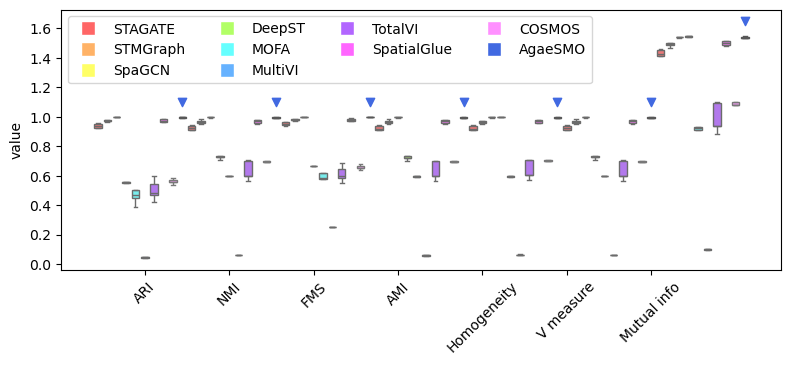

In [10]:
plt.figure(figsize=(8, 4))
for n,i in enumerate(dfs[0].columns):
    sns.boxplot(x=n*10,y=dfs[0][i],color="#FF6666",showfliers=False)
    sns.boxplot(x=n*10+1,y=dfs[1][i],color="#FFB266",showfliers=False)
    sns.boxplot(x=n*10+2,y=dfs[2][i],color="#FFFF66",showfliers=False)
    sns.boxplot(x=n*10+3,y=dfs[3][i],color="#B2FF66",showfliers=False)
    sns.boxplot(x=n*10+4,  y=dfs[4][i],color="#66FFFF",showfliers=False)
    sns.boxplot(x=n*10+5,y=dfs[5][i],color="#66B2FF",showfliers=False)
    sns.boxplot(x=n*10+6,y=dfs[6][i],color="#B266FF",showfliers=False)
    sns.boxplot(x=n*10+7,y=dfs[7][i],color="#FF66FF",showfliers=False)
    sns.boxplot(x=n*10+8,y=dfs[8][i],color="#FF90FF",showfliers=False)
    sns.boxplot(x=n*10+9,y=dfs[9][i],color="#4169E1",showfliers=False)
    
    plt.scatter(n*10+9, max(dfs[9][i])+0.1, marker='v', color='#4169E1')
    
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='STAGATE',       markerfacecolor="#FF6666", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='STMGraph',      markerfacecolor="#FFB266", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='SpaGCN',        markerfacecolor="#FFFF66", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='DeepST',        markerfacecolor="#B2FF66", markersize=10),

    Line2D([0], [0], marker='s', color='w', label='MOFA',          markerfacecolor="#66FFFF", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='MultiVI',       markerfacecolor="#66B2FF", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='TotalVI',       markerfacecolor="#B266FF", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='SpatialGlue',   markerfacecolor="#FF66FF", markersize=10),
    
    Line2D([0], [0], marker='s', color='w', label='COSMOS',   markerfacecolor="#FF90FF", markersize=10),

    Line2D([0], [0], marker='s', color='w', label='AgaeSMO',         markerfacecolor="#4169E1", markersize=10),
]
plt.xticks(range(5,68,9), labels=["ARI","NMI","FMS","AMI","Homogeneity","V measure","Mutual info"],rotation=45,fontsize=10)

plt.legend(handles=legend_elements, ncol=4)
plt.ylabel("value")
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.25)
# plt.savefig("plot/fig2_e.png",dpi=600)

In [26]:
simulation=1
h5ad_path=glob.glob(f"comparison/STAGATE/*Simulation{simulation}_RNA.h5ad")
h5ad_path+=glob.glob(f"comparison/STMGraph/*Simulation{simulation}_RNA.h5ad")
h5ad_path+=glob.glob(f"comparison/spaGCN/*Simulation{simulation}_RNA.h5ad")
h5ad_path+=glob.glob(f"comparison/deepst/*Simulation{simulation}_RNA.h5ad")

h5ad_path+=glob.glob(f"comparison/MOFA/*Simulation{simulation}.h5ad")
h5ad_path+=glob.glob(f"comparison/multivi/*Simulation{simulation}.h5ad")
h5ad_path+=glob.glob(f"comparison/totalVI/*Simulation{simulation}.h5ad")
h5ad_path+=glob.glob(f"comparison/spatial_glue/*Simulation{simulation}.h5ad")
h5ad_path+=glob.glob(f"comparison/cosmos/*Simulation{simulation}.h5ad")

h5ad_path+=glob.glob(f"AgaeSMO/result/*Simulation{simulation}.h5ad")
h5ad_path

['comparison/STAGATE/Dataset13_Simulation1_RNA.h5ad',
 'comparison/STMGraph/Dataset13_Simulation1_RNA.h5ad',
 'comparison/spaGCN/Dataset13_Simulation1_RNA.h5ad',
 'comparison/deepst/Dataset13_Simulation1_RNA.h5ad',
 'comparison/MOFA/Dataset13_Simulation1.h5ad',
 'comparison/multivi/Dataset13_Simulation1.h5ad',
 'comparison/totalVI/Dataset13_Simulation1.h5ad',
 'comparison/spatial_glue/Dataset13_Simulation1.h5ad',
 'comparison/cosmos/Dataset13_Simulation1.h5ad',
 'AgaeSMO/result/Dataset13_Simulation1.h5ad']

In [27]:
# h5ad_path=[
#  'comparison/STAGATE/Dataset13_Simulation1_RNA.h5ad',
#  'comparison/STMGraph/Dataset13_Simulation1_RNA.h5ad',
#  'comparison/spaGCN/Dataset13_Simulation1_RNA.h5ad',
#  'comparison/deepst/Dataset13_Simulation1_RNA.h5ad',

#  'comparison/MOFA/Dataset13_Simulation1.h5ad',
# 'comparison/multivi/Dataset13_Simulation1.h5ad',
#  'comparison/totalVI/Dataset13_Simulation1.h5ad',
#  'comparison/spatial_glue/Dataset13_Simulation1.h5ad',
 
#  'v1.2_test_result/Dataset13_Simulation1.h5ad'
#  ]

In [28]:
adatas=[]
for i in h5ad_path:
    adata_i=sc.read_h5ad(i)
    adatas.append(adata_i)
    print(i)
    print(adata_i)

comparison/STAGATE/Dataset13_Simulation1_RNA.h5ad
AnnData object with n_obs × n_vars = 1296 × 1000
    obs: 'mclust'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Spatial_Net', 'hvg', 'log1p', 'neighbors', 'umap'
    obsm: 'STAGATE', 'X_umap', 'nsfac', 'spatial', 'spfac'
    varm: 'nsload', 'spload'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
comparison/STMGraph/Dataset13_Simulation1_RNA.h5ad
AnnData object with n_obs × n_vars = 1296 × 1000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'log1p_total_counts_ercc', 'pct_counts_ercc', 'mclust', 'refine_mclust'
    var: 'mt', 'ercc', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total

In [29]:
obsm_key=["STAGATE","STMGraph",None,"X_mofa","X_MultiVI","X_totalVI","SpatialGlue","cosmos","AgaeSMO"]
print(adatas[4])
print(adatas[5])
print(adatas[6])
search_res(adatas[4],n_clusters=5,use_rep="X_mofa",start=0.1, end=1.0, increment=0.005)
search_res(adatas[5],n_clusters=5,use_rep="X_MultiVI",start=0.1, end=0.2, increment=0.005)
search_res(adatas[6],n_clusters=5,use_rep="X_totalVI",start=0.1, end=0.25, increment=0.005)


AnnData object with n_obs × n_vars = 1296 × 1000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca'
    obsm: 'X_mofa', 'X_pca', 'nsfac', 'spatial', 'spfac'
    varm: 'PCs', 'nsload', 'spload'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 1296 × 1100
    obs: 'modality', '_indices', '_scvi_batch', '_scvi_labels'
    var: 'modality', 'n_cells'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_MultiVI', 'spatial'
AnnData object with n_obs × n_vars = 1296 × 1000
    obs: 'batch', '_scvi_batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p'
    obsm: 'X_totalVI', 'nsfac', 'spatial', 'spfac'
    varm

0.18500000000000008

In [30]:
ground_truth=1*np.array(adatas[8].obsm['spfac'][:,0] + 2*adatas[8].obsm['spfac'][:,1] + 3*adatas[8].obsm['spfac'][:,2] + 4*adatas[8].obsm['spfac'][:,3])
ground_truth=[str(int(i)) for i in ground_truth]
adatas[8].obs['Ground Truth']=  ground_truth

In [31]:
adatas[8].obs['Ground Truth']

529     2
478     1
234     2
64      2
1087    3
       ..
956     0
734     0
1104    4
398     1
1190    3
Name: Ground Truth, Length: 1296, dtype: object

In [32]:
# adatas[8].uns['Ground Truth_colors']=adatas[8].uns["AgaeSMO_colors"]

/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Ground Truth'}, xlabel='spatial1', ylabel='spatial2'>

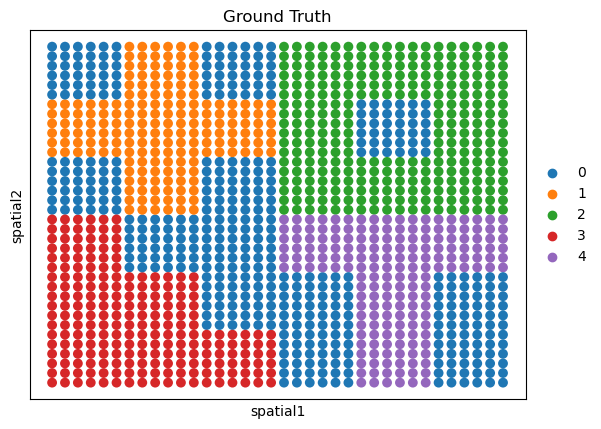

In [33]:
# adatas[8].uns["AgaeSMO_colors"]
sc.pl.embedding(adatas[8], basis='spatial',color="Ground Truth",title=f"Ground Truth",s=200, show=False)


In [34]:
obs=[

"mclust",              
"refine_mclust",       
"refined_pred",        
"DeepST_refine_domain",
  
"leiden",     
"leiden",  
"leiden",  
"SpatialGlue",
    
"Cluster_cosmos",

"AgaeSMO",    
]
obsm=[
    "STAGATE",
    "STMGraph",
    None,
    "DeepST_embed",

    "X_mofa",
    "X_MultiVI",
    "X_totalVI",
    "SpatialGlue",
    "cosmos",
    
    "AgaeSMO"

]
ARIs=[]
from sklearn import metrics
for n,i in enumerate(adatas):
    ARI = metrics.adjusted_rand_score(adatas[8].obs['Ground Truth'],i.obs[obs[n]])
    ARIs.append(round(ARI,4))
print(ARIs)

[0.9569, 0.9675, 0.7265, 0.5513, 0.6021, 0.0424, 0.4188, 0.9848, 0.5733, 1.0]


In [35]:
adatas[1]

AnnData object with n_obs × n_vars = 1296 × 1000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'log1p_total_counts_ercc', 'pct_counts_ercc', 'mclust', 'refine_mclust'
    var: 'mt', 'ercc', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Spatial_Net', 'hvg', 'log1p'
    obsm: 'STMGraph', 'nsfac', 'spatial', 'spfac'
    varm: 'nsload', 'spload'
    layers: 'counts'

/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software

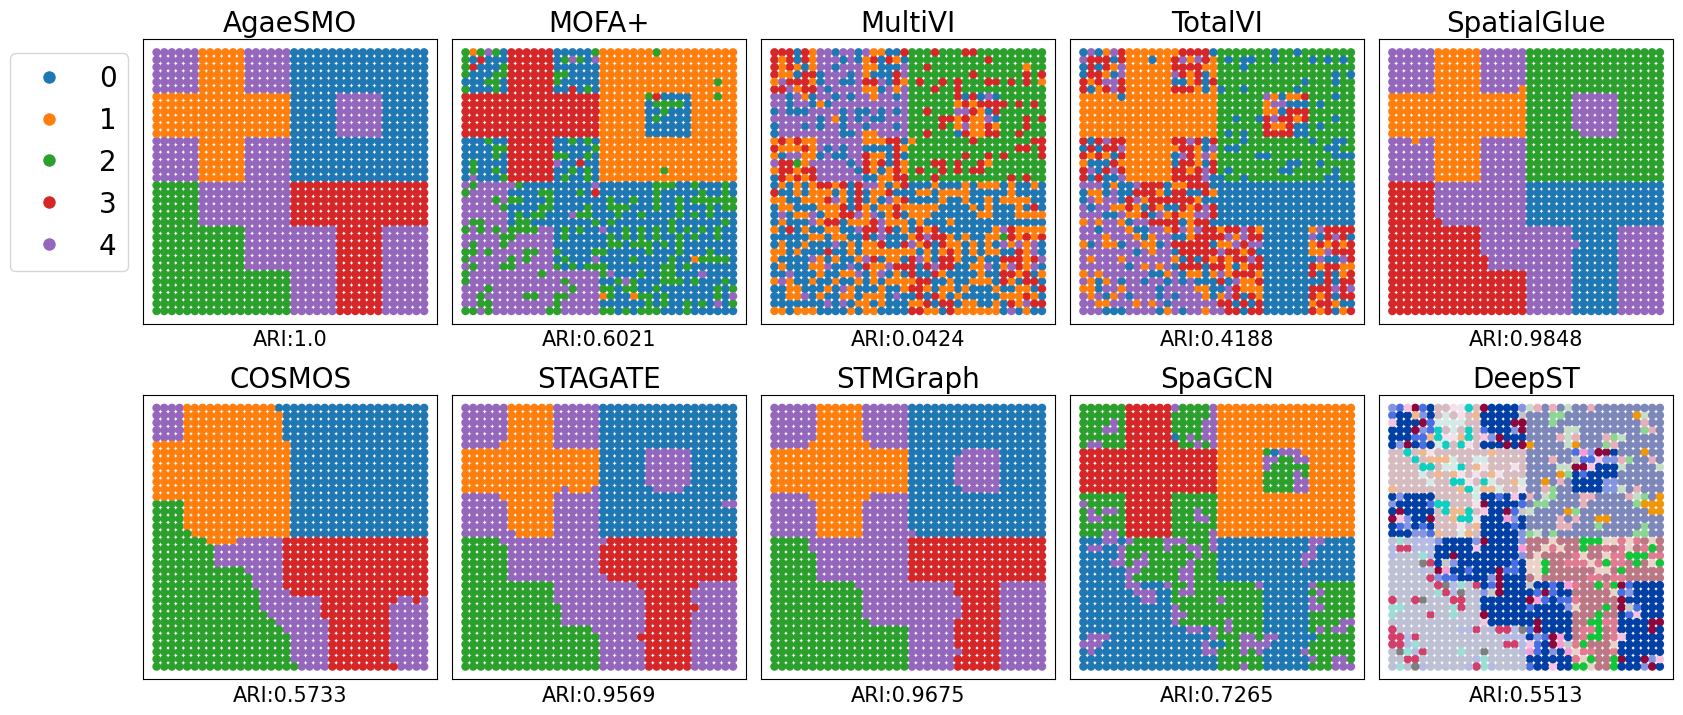

In [36]:

fig,ax=plt.subplots(2,5,figsize=(18,8))
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.95, top=0.9, wspace=0.05, hspace=0.25)
size=150
obs_key=["mclust","refine_mclust",'refined_pred','DeepST_refine_domain',"leiden",'leiden','leiden','SpatialGlue','AgaeSMO']
sc.pl.embedding(adatas[0], basis='spatial',color='mclust',       title=f"STAGATE",      ax=ax[1,1] ,s=size, show=False)
sc.pl.embedding(adatas[1], basis='spatial',color='refine_mclust',title=f"STMGraph",     ax=ax[1,2] ,s=size, show=False)
sc.pl.embedding(adatas[2], basis='spatial',color='refined_pred',title=f"SpaGCN",        ax=ax[1,3] ,s=size, show=False)
sc.pl.embedding(adatas[3], basis='spatial',color='DeepST_refine_domain',title=f"DeepST",ax=ax[1,4] ,s=size, show=False)

sc.pl.embedding(adatas[4], basis='spatial',color="leiden",title=f"MOFA+",           ax=ax[0,1] ,s=size, show=False)
sc.pl.embedding(adatas[5], basis='spatial',color="leiden",title=f"MultiVI",         ax=ax[0,2] ,s=size, show=False)
sc.pl.embedding(adatas[6], basis='spatial',color="leiden",title=f"TotalVI",         ax=ax[0,3] ,s=size, show=False)
sc.pl.embedding(adatas[7], basis='spatial',color="SpatialGlue",title=f"SpatialGlue",ax=ax[0,4] ,s=size, show=False)

sc.pl.embedding(adatas[8], basis='spatial',color="Cluster_cosmos",title=f"COSMOS",ax=ax[1,0] ,s=size, show=False)

sc.pl.embedding(adatas[9], basis='spatial',color="AgaeSMO",title=f"AgaeSMO",ax=ax[0,0] ,s=size, show=False)
# sc.pl.embedding(adatas[8], basis='spatial',color="Ground Truth",title=f"Ground Truth",ax=ax[1,0] ,s=size, show=False)
for i in ax:
    for j in i:
        j.set_xlabel(None)
        j.set_ylabel(None)
        j.set_title(j.title.get_text(), fontsize=20)
        legend = j.legend()
        legend.set_visible(False)  # 隐藏图例

ax[1,1].set_xlabel(f"ARI:{ARIs[0]}", fontsize=15)
ax[1,2].set_xlabel(f"ARI:{ARIs[1]}", fontsize=15)
ax[1,3].set_xlabel(f"ARI:{ARIs[2]}", fontsize=15)
ax[1,4].set_xlabel(f"ARI:{ARIs[3]}", fontsize=15)

ax[0,1].set_xlabel(f"ARI:{ARIs[4]}", fontsize=15)
ax[0,2].set_xlabel(f"ARI:{ARIs[5]}", fontsize=15)
ax[0,3].set_xlabel(f"ARI:{ARIs[6]}", fontsize=15)
ax[0,4].set_xlabel(f"ARI:{ARIs[7]}", fontsize=15)

ax[1,0].set_xlabel(f"ARI:{ARIs[8]}", fontsize=15)

ax[0,0].set_xlabel(f"ARI:{ARIs[9]}", fontsize=15)


legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='0',       markerfacecolor=adatas[0].uns["mclust_colors"][0], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='1',      markerfacecolor=adatas[0].uns["mclust_colors"][1], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='2',        markerfacecolor=adatas[0].uns["mclust_colors"][2], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='3',        markerfacecolor=adatas[0].uns["mclust_colors"][3], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='4',         markerfacecolor=adatas[0].uns["mclust_colors"][4], markersize=10),
]
ax[0,0].legend(handles=legend_elements, ncol=1,loc= 'upper left' ,fontsize=20,bbox_to_anchor=(-0.5, 1))
# ax[1,0].set_xlabel(None)
# ax[1,0].set_ylabel(None)
# ax[1,0].xaxis.set_visible(False) 
# ax[1,0].yaxis.set_visible(False) 
# ax[1,0].spines['top'].set_visible(False)
# ax[1,0].spines['right'].set_visible(False)
# ax[1,0].spines['left'].set_visible(False)
# ax[1,0].spines['bottom'].set_visible(False)

# fig.savefig(f"plot/fig2_f_{simulation}",dpi=600)

/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Ground Truth'}, xlabel='spatial1', ylabel='spatial2'>

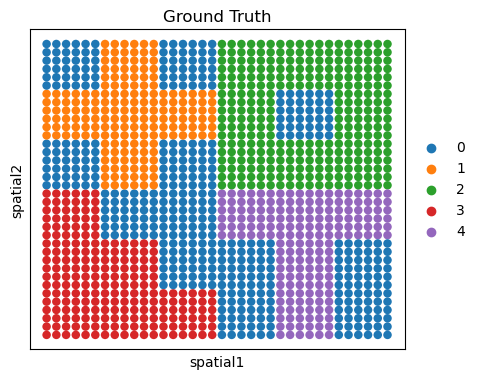

In [37]:
fig,ax=plt.subplots(figsize=(5,4))
plt.subplots_adjust(left=0.05, bottom=0.1, right=0.8, top=0.9, wspace=0.05, hspace=0.25)
sc.pl.embedding(adatas[8], basis='spatial',color="Ground Truth",title=f"Ground Truth" ,ax=ax,s=size, show=False)
# fig.savefig(f"plot/fig2_g.png",dpi=600)

In [38]:
adatas[8]

AnnData object with n_obs × n_vars = 1296 × 1000
    obs: 'n_counts', 'x_pos', 'y_pos', 'Cluster_cosmos', 'Ground Truth'
    uns: 'WNN', 'log1p', 'Ground Truth_colors', 'Cluster_cosmos_colors'
    obsm: 'Omics1_PCA', 'Omics1_PCA_norm', 'Omics2_PCA', 'Omics2_PCA_norm', 'Weights', 'cosmos', 'nsfac', 'spatial', 'spfac'
    varm: 'nsload', 'spload'
    layers: 'counts'
    obsp: 'WNN', 'WNN_distance'

In [39]:
def plot_weight_value(alpha, label, modality1='mRNA', modality2='protein',show=True):
  """\
  Plotting weight values
  
  """  
  import pandas as pd  
  
  df = pd.DataFrame(columns=[modality1, modality2, 'label'])  
  df[modality1], df[modality2] = alpha[:, 0], alpha[:, 1]
  df['label'] = label
  df = df.set_index('label').stack().reset_index()
  df.columns = ['label', 'Modality', 'Weight value']
  ax = sns.violinplot(data=df, y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
  ax.set_title(modality1 + ' vs ' + modality2) 

  plt.tight_layout(w_pad=0.05)
  if show:
    plt.show()  

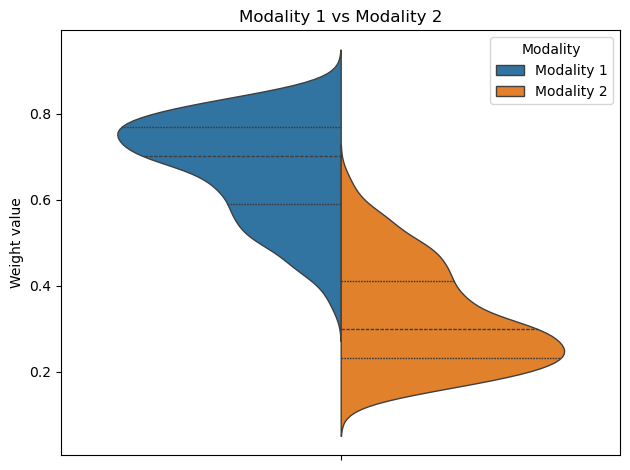

In [40]:
plot_weight_value(adatas[9].obsm["alpha"],"AgaeSMO",modality1='Modality 1', modality2='Modality 2',)

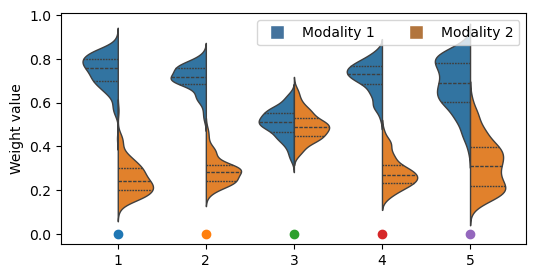

In [41]:
import seaborn as sns
def plot_weight_value(alpha, label, modality1='mRNA', modality2='protein',show=True):
  """\
  Plotting weight values
  
  """  
  import pandas as pd  
  
  df = pd.DataFrame(columns=[modality1, modality2, 'label'])  
  df[modality1], df[modality2] = alpha[:, 0], alpha[:, 1]
  df['label'] = label
  df = df.set_index('label').stack().reset_index()
  df.columns = ['label', 'Modality', 'Weight value']
  return df
  ax = sns.violinplot(data=df, y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
  ax.set_title(modality1 + ' vs ' + modality2) 

  plt.tight_layout(w_pad=0.05)
  if show:
    plt.show() 
from matplotlib.lines import Line2D
fig,ax=plt.subplots(1,figsize=(6,3))




for n,i in enumerate(set(adatas[9].obs["AgaeSMO"])):
    alpha=adatas[9].obsm["alpha"][adatas[9].obs["AgaeSMO"]==i,:]
    
    df=plot_weight_value(alpha,"AgaeSMO",modality1='mRNA', modality2='MSI')
    sns.violinplot(data=df,ax=ax,x=n+1,y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
    
    ax.scatter(n,0,c=adatas[9].uns["AgaeSMO_colors"][n])
ax.legend().set_visible(False)
#     ax[j].set_title(titles[j])
#     legend = ax[j].legend()
#     legend.set_visible(False)
#     # break
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Modality 1',       markerfacecolor="#44739d", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Modality 2',       markerfacecolor="#b2753d", markersize=10),
]
ax.legend(handles=legend_elements, ncol=2,loc= 'upper right' ,fontsize=10)
# fig.savefig("plot/fig2_simulation_alpha.png",dpi=600)